## 1. Information extraction
Define functions that extract the values from simulation output data. 

In [1]:
# functions for information extraction
import pandas as pd
import ast
import re

# extract configuration information
def extract_config(lines):
    switch_config_target = "Switch configurations:"
    pctrl_only_target = "'--pctrl-only'"
    data = {}
    found_switch_config = False
    for _, line in enumerate(lines):
        if pctrl_only_target in line:
            pctrl_only_str = line.strip().replace("--", "").split(':')[1].strip()
            pctrl_only = ast.literal_eval(pctrl_only_str)
            data['pctrl_only'] = pctrl_only[0]
        elif switch_config_target in line:
            found_switch_config = True
        elif found_switch_config:
            # Safely evaluate the config string to a Python list containing a dictionary
            item_list = ast.literal_eval(line)
            if isinstance(item_list, list) and len(item_list) > 0 and isinstance(item_list[0], dict):
                record = item_list[0]
                ctrl_id = record.get('ctrl_id')
                thresh = record.get('thresh', {})
                time_delay = thresh.get('time_delay')
                cross_lane_headway = thresh.get('cross_lane_headway')
                data['ctrl_id'] = ctrl_id
                data['time_delay'] = time_delay
                data['cross_lane_headway'] = cross_lane_headway        
            found_switch_config = False  
    return data

# extract delay time
def extract_det_delay_time(lines):
    target = '--deterministic-delay'
    for _, line in enumerate(lines):
        if target in line:
            target_str = line.split(':')[1].replace("'", "").replace(",", "").strip()
            target_val = float(target_str)
            return target_val

# extract switch probabilities
def extract_switch_probs(lines):
    _dict = {}
    for line in lines:
        if line.startswith("[probabilities]"):
            # Use regular expression to find all numbers in the line
            numbers_str = re.findall(r"[-+]?\d*\.\d+|\d+", line)
            if len(numbers_str) >= 2:
                try:
                    _dict["prob_pri_ctrl"] = float(numbers_str[0])
                    _dict["prob_sec_ctrl"] = 1 - float(numbers_str[0])
                except ValueError:
                    print(f"Warning: Could not convert first two elements to numbers in line: {line.strip()}")
    return _dict

# extract exit probabilities 
def extract_exit_probs(lines):
    _dict = {}
    for line in lines:
        if line.startswith("[counts]"):
            # Use regular expression to find all numbers in the line
            numbers_str = re.findall(r"[-+]?\d*\.\d+|\d+", line)
            if len(numbers_str) >= 3:
                try:
                    num1 = int(numbers_str[1])
                    num2 = int(numbers_str[2])
                    if num1 * num2 < 0 or num1 + num2 <= 0:
                        raise ValueError("Both counts must be non-negative and at least one count must be positive")
                    p = num1 / float(num1 + num2)
                    _dict["prob_exit_sec_ctrl"] = p
                    _dict["prob_stay_in_sec_ctrl"] = 1 - p
                except ValueError:
                    print(f"Warning: Could not convert first three elements to numbers in line: {line.strip()}")
    return _dict

def extract_metrics_data_to_df(lines):
    extracted_data = [] 
    for line in lines:
        if line.startswith("[data]"):
                data_part = line[len("[data]"):].strip()
                pairs = data_part.split(', ')
                data_dict = {}
                for pair in pairs:
                    if ':' in pair:
                        key, value = pair.split(': ', 1)
                        data_dict[key.strip()] = value.strip()
                extracted_data.append(data_dict)
    if extracted_data:
        df = pd.DataFrame(extracted_data)
        df['headway'] = df['headway'].astype('float')
        # df['cross_lane_headway'] = df['cross_lane_headway'].astype('float')
        df['ttc'] = df['ttc'].astype('float')
        def bool_str_to_num(x):
            if x=='True':
                return 1  
            else:
                return 0
        df['on lane'] = df['on lane'].apply(bool_str_to_num)
        df = df.drop(['cross_lane_headway'], axis=1)
        return df
    else:
        raise ValueError("Empty data")  # Return an empty DataFrame

HEADWAY_THRESH = 7
TTC_THRESH = 70
print(f"HEADWAY_THRESH = {HEADWAY_THRESH}")
print(f"TTC_THRESH = {TTC_THRESH}")

# extract metrics
def generate_metrics_statistics(lines, headway_thresh=HEADWAY_THRESH, ttc_thresh=TTC_THRESH):     
    df = extract_metrics_data_to_df(lines)
    n_rows = len(df)
    proportions = {}

    for val3 in [0, 1]:
        for op2 in ['le', 'gt']:
            for op1 in ['le', 'gt']:
                subset_name = f"headway_{op1}_ttc_{op2}_on_lane_{val3}"

                condition1 = (df.iloc[:, 0] <= headway_thresh) if op1 == 'le' else (df.iloc[:, 0] > headway_thresh)
                condition2 = (df.iloc[:, 1] <= ttc_thresh) if op2 == 'le' else (df.iloc[:, 1] > ttc_thresh)
                condition3 = (df.iloc[:, 2] == val3)

                subset = df[condition1 & condition2 & condition3]
                proportions[subset_name] = len(subset) / n_rows if n_rows > 0 else 0.0

    return proportions

HEADWAY_THRESH = 7
TTC_THRESH = 70


## 2. Evaluation of Agent Performance with Varying Time Delays

In [2]:
import os
# directory of input data for exp 1
current_folder = os.getcwd()
parent_folder = os.path.abspath(os.path.join(current_folder, os.pardir))
input_dir_1 = parent_folder + "/out/highway_env_continuous_actions/experiment/run1"
input_dir_1

'/home/guoxin/PycharmProjects/realtime-drl-switch/scripts/out/highway_env_continuous_actions/experiment/run1'

In [3]:
list_of_dfs = []
i = 0
for root, _, files in os.walk(input_dir_1):
        for file in files:
            if file.endswith("log.txt"):
                file_path = os.path.join(root, file)
                try:
                    with open(file_path, 'r') as f:
                        lines = f.readlines()   
                        dt = extract_det_delay_time(lines)           
                        i += 1
                        df = extract_metrics_data_to_df(lines)
                        list_of_dfs.append((dt, df))
                except Exception as e:
                    print(f"Error reading file {file_path}: {e}")
import pandas as pd
list_of_dfs.sort(key=lambda item: item[0])

In [4]:
exp1_res_list = [];
for dt, df in list_of_dfs:
    headway_mean = df["headway"].mean()
    ttc_qt = df["ttc"].quantile(0.1)
    on_lane_mean = df["on lane"].mean()
    exp1_res_list.append([dt, headway_mean, ttc_qt, on_lane_mean])
column_names = ["delay_time", "headway_mean", "ttc_10pt", "on_lane_prob"]
exp1_res = pd.DataFrame(exp1_res_list, columns=column_names)
exp1_res = exp1_res[['delay_time', 'on_lane_prob', 'ttc_10pt', 'headway_mean']]
print(exp1_res.to_string())

    delay_time  on_lane_prob  ttc_10pt  headway_mean
0         0.00      0.999946  28.00644      5.599308
1         0.05      1.000000  27.82746      5.505549
2         0.10      0.999946  24.97830      4.669603
3         0.15      0.967215  20.65444      4.552694
4         0.20      0.768350  16.87709      4.855820
5         0.25      0.755695  16.54985      4.866956
6         0.30      0.459351  11.70912      5.036633
7         0.35      0.407633   9.51423      4.891624
8         0.40      0.367579   8.71588      5.110903
9         0.45      0.362171   8.84193      5.083313
10        0.50      0.369185   9.26670      5.631618


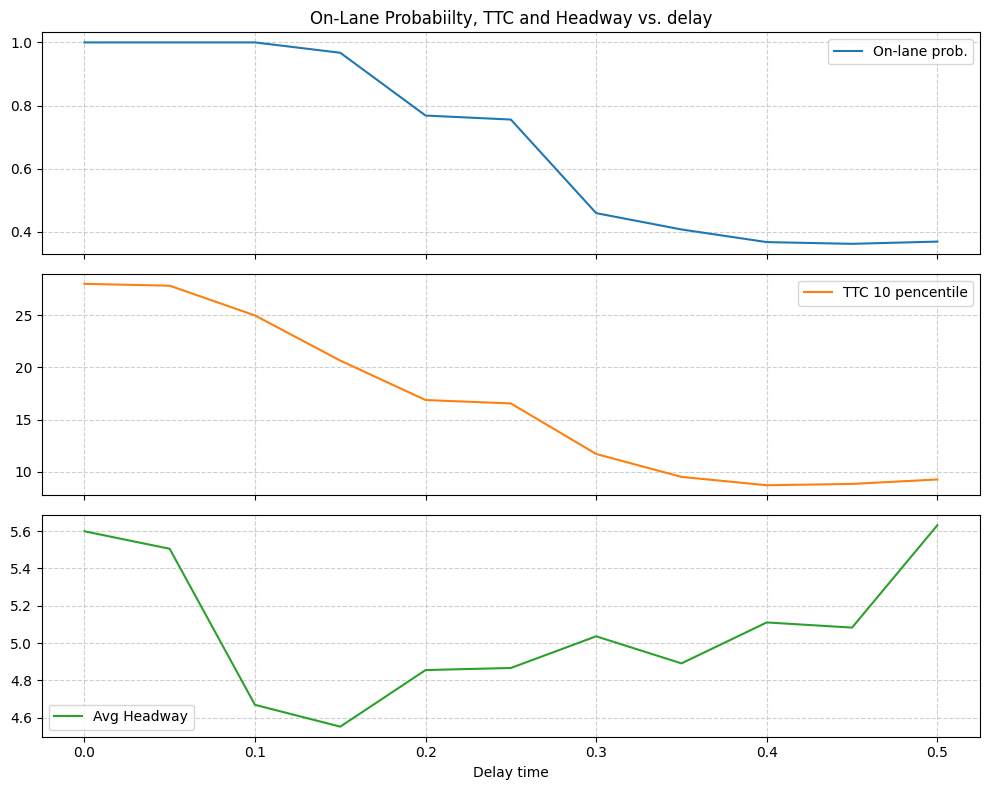

In [5]:
import matplotlib.pyplot as plt

# Create a figure and a set of subplots
# 3 rows, 1 column, sharing the x-axis
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 8))

# Plot each column on a different subplot
axes[0].plot(exp1_res['delay_time'], exp1_res['on_lane_prob'], label='On-lane prob.', color='C0') # Use 'C0', 'C1', ... for default colors
axes[1].plot(exp1_res['delay_time'], exp1_res['ttc_10pt'], label='TTC 10 pencentile', color='C1')
axes[2].plot(exp1_res['delay_time'], exp1_res['headway_mean'], label='Avg Headway', color='C2')

# Add titles and labels
axes[0].set_title('On-Lane Probabiilty, TTC and Headway vs. delay') # Main title or set suptitle on fig
axes[0].set_ylabel('')
axes[1].set_ylabel('')
axes[2].set_ylabel('')
axes[2].set_xlabel('Delay time') # Only the bottom subplot needs the x-label

# Add legends to each subplot
axes[0].legend()
axes[1].legend()
axes[2].legend()

# Optional: Add grid
for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.6)

# Improve layout
plt.tight_layout()
# Adjust layout to prevent the suptitle from overlapping the top plot
#fig.suptitle('Data from Columns b, c, and d vs. a (Separate Scales)', y=1.02)

# Show the plot
plt.show()

## 3. Design a Switch Model with Optimal Parameters

In [6]:
import os
current_folder = os.getcwd()
parent_folder = os.path.abspath(os.path.join(current_folder, os.pardir))
input_dir_2 = parent_folder + "/out/highway_env_continuous_actions/experiment/run2"

In [7]:
list_of_dicts = []
directory = input_dir_2
for root, _, files in os.walk(directory):
        for file in files:
            if file.endswith("log.txt"):
                print("file name: ", file)
                file_path = os.path.join(root, file)
                try:
                    with open(file_path, 'r') as f:
                        lines = f.readlines()
                        _dict = extract_config(lines)
                        _dict.update(extract_switch_probs(lines))
                        _dict.update(extract_exit_probs(lines))
                        _dict.update(generate_metrics_statistics(lines))
                        list_of_dicts.append(_dict)
                except Exception as e:
                    print(f"Error reading file {file_path}: {e}")
import pandas as pd
list_of_dicts0 = [x for x in list_of_dicts if x['pctrl_only']==True]
list_of_dicts1 = [x for x in list_of_dicts if x['pctrl_only']==False]
df0 = pd.DataFrame(list_of_dicts0)
df1 = pd.DataFrame(list_of_dicts1)
df = pd.concat([df0, df1], ignore_index=True)
config = 'config'
new_column_data = ['c0', 'c1', 'c2', 'c3', 'c4']
df.insert(0, config, new_column_data)
df = df.set_index('config')
df

file name:  log.txt
file name:  log.txt
file name:  log.txt
file name:  log.txt
file name:  log.txt


,pctrl_only,ctrl_id,time_delay,cross_lane_headway,prob_pri_ctrl,prob_sec_ctrl,headway_le_ttc_le_on_lane_0,headway_gt_ttc_le_on_lane_0,headway_le_ttc_gt_on_lane_0,headway_gt_ttc_gt_on_lane_0,headway_le_ttc_le_on_lane_1,headway_gt_ttc_le_on_lane_1,headway_le_ttc_gt_on_lane_1,headway_gt_ttc_gt_on_lane_1,prob_exit_sec_ctrl,prob_stay_in_sec_ctrl
config,,,,,,,,,,,,,,,,
c0,True,ctrl_1,0.2,4.0,1.000000,0.000000,0.085616,0.003387,0.050809,0.014104,0.355224,0.004205,0.408369,0.078287,NaN,NaN
c1,False,ctrl_1,0.1,4.0,0.393487,0.606513,0.030565,0.006542,0.079656,0.125730,0.184012,0.017595,0.281996,0.273904,0.445115,0.554885
c2,False,ctrl_1,0.2,4.0,0.610740,0.389260,0.051674,0.008016,0.081721,0.086623,0.289109,0.011419,0.317368,0.154070,0.299117,0.700883
c3,False,ctrl_2,0.1,4.0,0.393487,0.606513,0.027787,0.005866,0.075783,0.124789,0.183732,0.017178,0.285562,0.279303,0.397167,0.602833
c4,False,ctrl_2,0.2,4.0,0.610740,0.389260,0.048480,0.006632,0.080539,0.085925,0.296003,0.011295,0.317984,0.153142,0.307680,0.692320


In [8]:
# Get the value using .loc
c1_prob_pri_ctrl = df.loc['c1', 'prob_pri_ctrl']
c2_prob_pri_ctrl = df.loc['c2', 'prob_pri_ctrl']
c3_prob_pri_ctrl = df.loc['c3', 'prob_pri_ctrl']
c4_prob_pri_ctrl = df.loc['c4', 'prob_pri_ctrl']

c1_prob_exit_sec_ctrl = df.loc['c1', 'prob_exit_sec_ctrl']
c2_prob_exit_sec_ctrl = df.loc['c2', 'prob_exit_sec_ctrl']
c3_prob_exit_sec_ctrl = df.loc['c3', 'prob_exit_sec_ctrl']
c4_prob_exit_sec_ctrl = df.loc['c4', 'prob_exit_sec_ctrl']

c1_headway_le_ttc_le_on_lane_0 = df.loc['c1', 'headway_le_ttc_le_on_lane_0']
c2_headway_le_ttc_le_on_lane_0 = df.loc['c2', 'headway_le_ttc_le_on_lane_0']
c3_headway_le_ttc_le_on_lane_0 = df.loc['c3', 'headway_le_ttc_le_on_lane_0']
c4_headway_le_ttc_le_on_lane_0 = df.loc['c4', 'headway_le_ttc_le_on_lane_0']

c1_headway_le_ttc_le_on_lane_1 = df.loc['c1', 'headway_le_ttc_le_on_lane_1']
c2_headway_le_ttc_le_on_lane_1 = df.loc['c2', 'headway_le_ttc_le_on_lane_1']
c3_headway_le_ttc_le_on_lane_1 = df.loc['c3', 'headway_le_ttc_le_on_lane_1']
c4_headway_le_ttc_le_on_lane_1 = df.loc['c4', 'headway_le_ttc_le_on_lane_1']

c1_headway_le_ttc_gt_on_lane_0 = df.loc['c1', 'headway_le_ttc_gt_on_lane_0']
c2_headway_le_ttc_gt_on_lane_0 = df.loc['c2', 'headway_le_ttc_gt_on_lane_0']
c3_headway_le_ttc_gt_on_lane_0 = df.loc['c3', 'headway_le_ttc_gt_on_lane_0']
c4_headway_le_ttc_gt_on_lane_0 = df.loc['c4', 'headway_le_ttc_gt_on_lane_0']

c1_headway_le_ttc_gt_on_lane_1 = df.loc['c1', 'headway_le_ttc_gt_on_lane_1']
c2_headway_le_ttc_gt_on_lane_1 = df.loc['c2', 'headway_le_ttc_gt_on_lane_1']
c3_headway_le_ttc_gt_on_lane_1 = df.loc['c3', 'headway_le_ttc_gt_on_lane_1']
c4_headway_le_ttc_gt_on_lane_1 = df.loc['c4', 'headway_le_ttc_gt_on_lane_1']

c1_headway_gt_ttc_le_on_lane_0 = df.loc['c1', 'headway_gt_ttc_le_on_lane_0']
c2_headway_gt_ttc_le_on_lane_0 = df.loc['c2', 'headway_gt_ttc_le_on_lane_0']
c3_headway_gt_ttc_le_on_lane_0 = df.loc['c3', 'headway_gt_ttc_le_on_lane_0']
c4_headway_gt_ttc_le_on_lane_0 = df.loc['c4', 'headway_gt_ttc_le_on_lane_0']

c1_headway_gt_ttc_le_on_lane_1 = df.loc['c1', 'headway_gt_ttc_le_on_lane_1']
c2_headway_gt_ttc_le_on_lane_1 = df.loc['c2', 'headway_gt_ttc_le_on_lane_1']
c3_headway_gt_ttc_le_on_lane_1 = df.loc['c3', 'headway_gt_ttc_le_on_lane_1']
c4_headway_gt_ttc_le_on_lane_1 = df.loc['c4', 'headway_gt_ttc_le_on_lane_1']

c1_headway_gt_ttc_gt_on_lane_0 = df.loc['c1', 'headway_gt_ttc_gt_on_lane_0']
c2_headway_gt_ttc_gt_on_lane_0 = df.loc['c2', 'headway_gt_ttc_gt_on_lane_0']
c3_headway_gt_ttc_gt_on_lane_0 = df.loc['c3', 'headway_gt_ttc_gt_on_lane_0']
c4_headway_gt_ttc_gt_on_lane_0 = df.loc['c4', 'headway_gt_ttc_gt_on_lane_0']

In [9]:
prism_model = \
f"""
mdp

// constants
const int MAX_CT=20; //max number of calls in total
const int MIN_CC=4; //min num of consecutive calls to a sec controller 

// switch probablities (to the primary controller)
const double sw1 = {c1_prob_pri_ctrl}; 
const double sw2 = {c2_prob_pri_ctrl}; 
const double sw3 = {c3_prob_pri_ctrl}; 
const double sw4 = {c4_prob_pri_ctrl}; 

// exit probablities (from a secondary controller)
const double ex1 = {c1_prob_exit_sec_ctrl}; 
const double ex2 = {c2_prob_exit_sec_ctrl}; 
const double ex3 = {c3_prob_exit_sec_ctrl}; 
const double ex4 = {c4_prob_exit_sec_ctrl}; 

// metric probabilities
// 1st group
const double lln1 = {c1_headway_le_ttc_le_on_lane_0};
const double lln2 = {c2_headway_le_ttc_le_on_lane_0};
const double lln3 = {c3_headway_le_ttc_le_on_lane_0};
const double lln4 = {c4_headway_le_ttc_le_on_lane_0};
// 2ed group
const double lly1 = {c1_headway_le_ttc_le_on_lane_1};
const double lly2 = {c2_headway_le_ttc_le_on_lane_1};
const double lly3 = {c3_headway_le_ttc_le_on_lane_1};
const double lly4 = {c4_headway_le_ttc_le_on_lane_1};
// 3rd group
const double lgn1 = {c1_headway_le_ttc_gt_on_lane_0};
const double lgn2 = {c2_headway_le_ttc_gt_on_lane_0};
const double lgn3 = {c3_headway_le_ttc_gt_on_lane_0};
const double lgn4 = {c4_headway_le_ttc_gt_on_lane_0};
// 4th group
const double lgy1 = {c1_headway_le_ttc_gt_on_lane_1};
const double lgy2 = {c2_headway_le_ttc_gt_on_lane_1};
const double lgy3 = {c3_headway_le_ttc_gt_on_lane_1};
const double lgy4 = {c4_headway_le_ttc_gt_on_lane_1};
// 5th group
const double gln1 = {c1_headway_gt_ttc_le_on_lane_0};
const double gln2 = {c2_headway_gt_ttc_le_on_lane_0};
const double gln3 = {c3_headway_gt_ttc_le_on_lane_0};
const double gln4 = {c4_headway_gt_ttc_le_on_lane_0};
// 6th group
const double gly1 = {c1_headway_gt_ttc_le_on_lane_1};
const double gly2 = {c2_headway_gt_ttc_le_on_lane_1};
const double gly3 = {c3_headway_gt_ttc_le_on_lane_1};
const double gly4 = {c4_headway_gt_ttc_le_on_lane_1};
// 7th group
const double ggn1 = {c1_headway_gt_ttc_gt_on_lane_0};
const double ggn2 = {c2_headway_gt_ttc_gt_on_lane_0};
const double ggn3 = {c3_headway_gt_ttc_gt_on_lane_0};
const double ggn4 = {c4_headway_gt_ttc_gt_on_lane_0};
// 8th group
const double ggy1 = 1-lln1-lly1-lgn1-lgy1-gln1-gly1-ggn1;
const double ggy2 = 1-lln2-lly2-lgn2-lgy2-gln2-gly2-ggn2;
const double ggy3 = 1-lln3-lly3-lgn3-lgy3-gln3-gly3-ggn3;
const double ggy4 = 1-lln4-lly4-lgn4-lgy4-gln4-gly4-ggn4;

module swtich
	
    //switch location variable
    loc : [0..4] init 0; 
    // 0: initialise, 1: determinie config, 2: select controller, 3: run controller, 4: done
    
    // controller
    ctrl: [0..1] init 0;
    // 0: primary (default), 1: secondary

    //configuration
    conf: [0..4] init 0;
    // 0: unspecified config, 1..4: configs

    //total count of calls
    ct: [0..MAX_CT] init 0;

    // count of consecutive calls to a secondary control
    cc: [0..MAX_CT] init 0;

    //safety metrics
    headway: [0..1] init 1;
    ttc: [0..1] init 1;
    onlane: [0..1] init 1;
    // 0: unsafe, 1: safe 

    // determinie configuration
    [] (loc=0) & (conf=0) & (ct < MAX_CT) -> (loc'=1) & (conf'=1);
    [] (loc=0) & (conf=0) & (ct < MAX_CT) -> (loc'=1) & (conf'=2);
    [] (loc=0) & (conf=0) & (ct < MAX_CT) -> (loc'=1) & (conf'=3);
    [] (loc=0) & (conf=0) & (ct < MAX_CT) -> (loc'=1) & (conf'=4);

    // switch to the primary controller or a secondary controller
    [] (loc=1) & (conf=1) -> sw1 : (loc'=2) & (ctrl'=0) + (1-sw1) : (loc'=2) & (ctrl'=1);
    [] (loc=1) & (conf=2) -> sw2 : (loc'=2) & (ctrl'=0) + (1-sw2) : (loc'=2) & (ctrl'=1);  
    [] (loc=1) & (conf=3) -> sw3 : (loc'=2) & (ctrl'=0) + (1-sw3) : (loc'=2) & (ctrl'=1);
    [] (loc=1) & (conf=4) -> sw4 : (loc'=2) & (ctrl'=0) + (1-sw4) : (loc'=2) & (ctrl'=1);

    // run the controller    
    [] (loc=2) & (conf=1) & (ct < MAX_CT) & (cc < MAX_CT) -> 
        lln1 : (loc'=3) & (headway'=0) & (ttc'=0) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) + 
        lly1 : (loc'=3) & (headway'=0) & (ttc'=0) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1) + 
        lgn1 : (loc'=3) & (headway'=0) & (ttc'=1) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) + 
        lgy1 : (loc'=3) & (headway'=0) & (ttc'=1) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1) + 
        gln1 : (loc'=3) & (headway'=1) & (ttc'=0) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) + 
        gly1 : (loc'=3) & (headway'=1) & (ttc'=0) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1) + 
        ggn1 : (loc'=3) & (headway'=1) & (ttc'=1) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) + 
        ggy1 : (loc'=3) & (headway'=1) & (ttc'=1) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1);
                             
    [] (loc=2) & (conf=2) & (ct < MAX_CT) & (cc < MAX_CT) -> 
        lln2 : (loc'=3) & (headway'=0) & (ttc'=0) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) + 
        lly2 : (loc'=3) & (headway'=0) & (ttc'=0) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1) + 
        lgn2 : (loc'=3) & (headway'=0) & (ttc'=1) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) + 
        lgy2 : (loc'=3) & (headway'=0) & (ttc'=1) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1) +  
        gln2 : (loc'=3) & (headway'=1) & (ttc'=0) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) + 
        gly2 : (loc'=3) & (headway'=1) & (ttc'=0) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1) +  
        ggn2 : (loc'=3) & (headway'=1) & (ttc'=1) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) + 
        ggy2 : (loc'=3) & (headway'=1) & (ttc'=1) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1);
                             
    [] (loc=2) & (conf=3) & (ct < MAX_CT) & (cc < MAX_CT) -> 
        lln3 : (loc'=3) & (headway'=0) & (ttc'=0) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) + 
        lly3 : (loc'=3) & (headway'=0) & (ttc'=0) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1) + 
        lgn3 : (loc'=3) & (headway'=0) & (ttc'=1) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) +  
        lgy3 : (loc'=3) & (headway'=0) & (ttc'=1) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1) + 
        gln3 : (loc'=3) & (headway'=1) & (ttc'=0) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) + 
        gly3 : (loc'=3) & (headway'=1) & (ttc'=0) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1) + 
        ggn3 : (loc'=3) & (headway'=1) & (ttc'=1) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) + 
        ggy3 : (loc'=3) & (headway'=1) & (ttc'=1) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1);

    [] (loc=2) & (conf=4) & (ct < MAX_CT) & (cc < MAX_CT) -> 
        lln4 : (loc'=3) & (headway'=0) & (ttc'=0) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) + 
        lly4 : (loc'=3) & (headway'=0) & (ttc'=0) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1) +
        lgn4 : (loc'=3) & (headway'=0) & (ttc'=1) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) +
        lgy4 : (loc'=3) & (headway'=0) & (ttc'=1) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1) +
        gln4 : (loc'=3) & (headway'=1) & (ttc'=0) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) +
        gly4 : (loc'=3) & (headway'=1) & (ttc'=0) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1) +
        ggn4 : (loc'=3) & (headway'=1) & (ttc'=1) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) +
        ggy4 : (loc'=3) & (headway'=1) & (ttc'=1) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1);
    
    // for primary controller, return
    [] (loc=3) & (ctrl=0) -> (loc'=4) & (headway'=1) & (ttc'=1) & (onlane'=1) & (cc'=0);

    // for a second controller, stay or return
    [] (loc=3) & (ctrl=1) & (cc < MIN_CC) -> (loc'=2);
    [] (loc=3) & (ctrl=1) & (cc >= MIN_CC) & (conf=1) -> (1-ex1): (loc'=2) + ex1: (loc'=4); 
    [] (loc=3) & (ctrl=1) & (cc >= MIN_CC) & (conf=2) -> (1-ex2): (loc'=2) + ex2: (loc'=4); 
    [] (loc=3) & (ctrl=1) & (cc >= MIN_CC) & (conf=3) -> (1-ex3): (loc'=2) + ex3: (loc'=4); 
    [] (loc=3) & (ctrl=1) & (cc >= MIN_CC) & (conf=4) -> (1-ex4): (loc'=2) + ex4: (loc'=4); 
            
    // reset
    [] (loc=4) -> (loc'=0) & (conf'=0) & (ctrl'=0) & (headway'=1) & (ttc'=1) & (onlane'=1) & (cc'=0);
    
    // terminal state, loop
    [] (loc=0) & (ct = MAX_CT) -> (loc'=0) & (ct' = MAX_CT);
    
endmodule

// rewards
rewards "ctrl_cost"
    [] loc=2 & ctrl=0 : 1/MAX_CT;
    [] loc=2 & ctrl=1 : 2/MAX_CT;
endrewards

rewards "headway_cost"
    [] loc=3 & headway=0 : 1/MAX_CT;
endrewards

rewards "ttc_cost"
    [] loc=3 & ttc=0 : 1/MAX_CT;
endrewards

rewards "onlane_cost"
    [] loc=3 & onlane=0 : 1/MAX_CT;
endrewards
"""


In [10]:
with open('switch_model.prism', 'w') as model_file:
    model_file.write(prism_model)

In [11]:
print(open('switch_model.prism', 'r').read())


mdp

// constants
const int MAX_CT=20; //max number of calls in total
const int MIN_CC=4; //min num of consecutive calls to a sec controller 

// switch probablities (to the primary controller)
const double sw1 = 0.39348720457881686; 
const double sw2 = 0.6107399723416943; 
const double sw3 = 0.39348720457881686; 
const double sw4 = 0.6107399723416943; 

// exit probablities (from a secondary controller)
const double ex1 = 0.44511475409836065; 
const double ex2 = 0.29911699779249445; 
const double ex3 = 0.3971674131461082; 
const double ex4 = 0.3076798444588464; 

// metric probabilities
// 1st group
const double lln1 = 0.030565346115888903;
const double lln2 = 0.05167392370022204;
const double lln3 = 0.027787133715055576;
const double lln4 = 0.04847958297132928;
// 2ed group
const double lly1 = 0.18401240659805443;
const double lly2 = 0.289108682487961;
const double lly3 = 0.18373189626136746;
const double lly4 = 0.2960034752389227;
// 3rd group
const double lgn1 = 0.0796559988721274

In [12]:
#f0 = "multi(R{\"ctrl_cost\"}<=1.85[ C ], R{\"onlane_cost\"}<=0.23[ C ], R{\"ttc_cost\"}<=0.24[ C ], R{\"headway_cost\"}<=0.6[ C ])"
f0 = "multi(R{\"ctrl_cost\"}<=1.85[ C ], R{\"headway_cost\"}<=0.6[ C ], R{\"onlane_cost\"}<=0.23[ C ], R{\"ttc_cost\"}<=0.24[ C ])"
#f0 = "multi(R{\"ctrl_cost\"}<=1.85[ C ], R{\"headway_cost\"}<=0.6[ C ], R{\"ttc_cost\"}<=0.24[ C ], R{\"onlane_cost\"}<=0.23[ C ])"
f1 = "multi(R{\"ctrl_cost\"}min=?[ C ])"
f2 = "multi(R{\"onlane_cost\"}min=?[ C ])"
f3 = "multi(R{\"ttc_cost\"}min=?[ C ])"
f4 = "multi(R{\"headway_cost\"}min=?[ C ])"
print(f0)
print(f1)
print(f2)
print(f3)
print(f4)

multi(R{"ctrl_cost"}<=1.85[ C ], R{"headway_cost"}<=0.6[ C ], R{"onlane_cost"}<=0.23[ C ], R{"ttc_cost"}<=0.24[ C ])
multi(R{"ctrl_cost"}min=?[ C ])
multi(R{"onlane_cost"}min=?[ C ])
multi(R{"ttc_cost"}min=?[ C ])
multi(R{"headway_cost"}min=?[ C ])


In [13]:
with open('switch_mo_prop.props', 'w') as property_file:
    property_file.write(f0)
print("--multi-objective property--") 
print(open('switch_mo_prop.props', 'r').read())
with open('safety_metrics.props', 'w') as safety_metrics_file:
    safety_metrics_file.write(f1)
    safety_metrics_file.write(';\n')
    safety_metrics_file.write(f2)
    safety_metrics_file.write(';\n')
    safety_metrics_file.write(f3)
    safety_metrics_file.write(';\n')
    safety_metrics_file.write(f4)
print("--single-objective properties--")
print(open('safety_metrics.props', 'r').read())

--multi-objective property--
multi(R{"ctrl_cost"}<=1.85[ C ], R{"headway_cost"}<=0.6[ C ], R{"onlane_cost"}<=0.23[ C ], R{"ttc_cost"}<=0.24[ C ])
--single-objective properties--
multi(R{"ctrl_cost"}min=?[ C ]);
multi(R{"onlane_cost"}min=?[ C ]);
multi(R{"ttc_cost"}min=?[ C ]);
multi(R{"headway_cost"}min=?[ C ])


In [14]:
import os
mopmc_home = os.getenv('MOPMC_HOME') 
storm_home = os.getenv('STORM_HOME') 
prism_home = os.getenv('PRISM_HOME') 
current_dir = os.getcwd()
parent_folder = os.path.abspath(os.path.join(current_folder, os.pardir))
test_model = os.path.join(mopmc_home, 'examples', 'multiobj_scheduler05.nm')
test_property = os.path.join(mopmc_home, 'examples', 'multiobj_scheduler05.pctl')
switch_model = os.path.join(current_dir, 'switch_model.prism')
switch_property = os.path.join(current_dir, 'switch_mo_prop.props')
safety_metrics_property = os.path.join(current_dir, 'safety_metrics.props')
prism_executable = os.path.join(prism_home, 'bin', 'prism')
storm_executable = os.path.join(storm_home, 'build', 'bin', 'storm')
mopmc_executable = os.path.join(mopmc_home, 'build', 'mopmc')
mopmc_export_folder = os.path.join(parent_folder, 'out', 'mopmc_output')

In [15]:
prism_command_swtich_model = f"{prism_executable} {switch_model} {switch_property}"
! $prism_command_swtich_model

PRISM
=====

Version: 4.4
Date: Tue Aug 05 10:48:15 AEST 2025
Hostname: guoxin-Precision-3660
Memory limits: cudd=1g, java(heap)=1g
Command line: prism /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_model.prism /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_mo_prop.props

Parsing model file "/home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_model.prism"...

Parsing properties file "/home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_mo_prop.props"...

1 property:
(1) multi(R{"ctrl_cost"}<=1.85 [ C ], R{"headway_cost"}<=0.6 [ C ], R{"onlane_cost"}<=0.23 [ C ], R{"ttc_cost"}<=0.24 [ C ])

Type:        MDP
Modules:     swtich 
Variables:   loc ctrl conf ct cc headway ttc onlane 

---------------------------------------------------------------------

Model checking: multi(R{"ctrl_cost"}<=1.85 [ C ], R{"headway_cost"}<=0.6 [ C ], R{"onlane_cost"}<=0.23 [ C ], R{"ttc_cost"}<=0.24 [ C ])

B

In [16]:
storm_command_test = f"{storm_executable} --prism {test_model} --prop {test_property}"
storm_command_swtich_model = f"{storm_executable} --prism {switch_model} --prop {switch_property}"
#! $storm_command_test
! $storm_command_swtich_model

Storm 1.8.2 (dev)

Date: Tue Aug  5 10:48:16 2025
Command line arguments: --prism /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_model.prism --prop /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_mo_prop.props
Current working directory: /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study

Time for model input parsing: 0.003s.

Time for model construction: 0.045s.

-------------------------------------------------------------- 
Model type: 	MDP (sparse)
States: 	19317
Transitions: 	68033
Choices: 	19377
Reward Models:  ttc_cost, onlane_cost, headway_cost, ctrl_cost
State Labels: 	2 labels
   * deadlock -> 640 item(s)
   * init -> 1 item(s)
Choice Labels: 	none
-------------------------------------------------------------- 

Model checking property "1": multi(R[exp]{"ctrl_cost"}<=37/20 [C], R[exp]{"headway_cost"}<=3/5 [C], R[exp]{"onlane_cost"}<=23/100 [C], R[exp]{"ttc_cost"}<=6/25 [C]) ...
Result (for initial states)

In [17]:
storm_command_safety_metrics = f"{storm_executable} --prism {switch_model} --prop {safety_metrics_property}"
! $storm_command_safety_metrics

Storm 1.8.2 (dev)

Date: Tue Aug  5 10:48:16 2025
Command line arguments: --prism /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_model.prism --prop /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/safety_metrics.props
Current working directory: /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study

Time for model input parsing: 0.002s.

Time for model construction: 0.045s.

-------------------------------------------------------------- 
Model type: 	MDP (sparse)
States: 	19317
Transitions: 	68033
Choices: 	19377
Reward Models:  ttc_cost, onlane_cost, headway_cost, ctrl_cost
State Labels: 	2 labels
   * deadlock -> 640 item(s)
   * init -> 1 item(s)
Choice Labels: 	none
-------------------------------------------------------------- 

Model checking property "1": multi(R[exp]{"ctrl_cost"}min=? [C]) ...
Result (for initial states): 1.773596707
Time for model checking: 0.034s.

Model checking property "2": multi(R[exp]{"onlane_co

In [18]:
mopmc_command_test = f"{mopmc_executable} -m {test_model} -p {test_property} -q achievability"
mopmc_achiev_switch_model = f"{mopmc_executable} -m {switch_model} -p {switch_property} -q achievability"
mopmc_convex_switch_model = f"{mopmc_executable} -m {switch_model} -p {switch_property} -q convex -c n -x {mopmc_export_folder}"
mopmc_convex_switch_model_non_exported = f"{mopmc_executable} -m {switch_model} -p {switch_property} -q convex -c n"
mopmc_export_switch_model = f"{mopmc_executable} -m {switch_model} -p {switch_property} -e {mopmc_export_folder}"

In [19]:
#! $mopmc_command_test
! $mopmc_achiev_switch_model

--Model Building--
States:	19317
Choices:	19377
Transitions:	68033
____ CUDA INITIALIZING ____
____ CUDA EXIT ____
----------------------------------------------
Achievability Query terminates after 1 iteration(s) 
OUTPUT: false
----------------------------------------------
--TIME STATISTICS--
Time for model construction: 0.080 second(s).
Time for data transformation: 0.001 second(s).
Time for model checking: 0.201 second(s), 0.201 per iteration.
Total time: 0.282 second(s).
Main loop count: 1

In [20]:
! $mopmc_export_switch_model

--Model Building--
States:	19317
Choices:	19377
Transitions:	68033
Successfully wrote state map to "/home/guoxin/PycharmProjects/realtime-drl-switch/scripts/out/mopmc_output/states.txt", 19318 lines in total
Successfully wrote transition matrix to "/home/guoxin/PycharmProjects/realtime-drl-switch/scripts/out/mopmc_output/transition_matrix.txt", 68034 lines in total


In [21]:
! $mopmc_convex_switch_model

--Model Building--
States:	19317
Choices:	19377
Transitions:	68033
____ CUDA INITIALIZING ____
[Main loop] Iteration: 0
[Project gradient - interior phase] finds minimum point at iteration: 3 (distance: 0)
[Minimum norm point optimization] exits for one vertex
[Main loop] Iteration: 1
[Main loop] Iteration: 2
[Project gradient - interior phase] finds minimum point at iteration: 2 (distance: 0)
[Minimum norm point optimization] max margin separation hyperplane computed, terminates at iteration: 4 (distance: 0.000114358685)
[Main loop] Iteration: 3
[Main loop] Iteration: 4
[Project gradient - interior phase] finds minimum point at iteration: 2 (distance: 4.717369003e-05)
[Minimum norm point optimization] max margin separation hyperplane computed, terminates at iteration: 566 (distance: 7.863633742e-06)
[Main loop] Iteration: 5
[Main loop] Iteration: 6
[Project gradient - interior phase] finds minimum point at iteration: 2 (distance: 6.016423026e-05)
[Minimum norm point optimization] max 

In [22]:
! $mopmc_convex_switch_model_non_exported

--Model Building--
States:	19317
Choices:	19377
Transitions:	68033
____ CUDA INITIALIZING ____
[Main loop] Iteration: 0
[Project gradient - interior phase] finds minimum point at iteration: 3 (distance: 0)
[Minimum norm point optimization] exits for one vertex
[Main loop] Iteration: 1
[Main loop] Iteration: 2
[Project gradient - interior phase] finds minimum point at iteration: 2 (distance: 0)
[Minimum norm point optimization] max margin separation hyperplane computed, terminates at iteration: 4 (distance: 0.000114358685)
[Main loop] Iteration: 3
[Main loop] Iteration: 4
[Project gradient - interior phase] finds minimum point at iteration: 2 (distance: 4.717369003e-05)
[Minimum norm point optimization] max margin separation hyperplane computed, terminates at iteration: 566 (distance: 7.863633742e-06)
[Main loop] Iteration: 5
[Main loop] Iteration: 6
[Project gradient - interior phase] finds minimum point at iteration: 2 (distance: 6.016423026e-05)
[Minimum norm point optimization] max 

In [23]:
f0_1 = "multi(R{\"ctrl_cost\"}<=1.883 [ C ], R{\"headway_cost\"}<=0.573[ C ], R{\"ttc_cost\"}<=0.235[ C ], R{\"onlane_cost\"}<=0.235[ C ])"
with open('switch_mo_acheivable_prop.props', 'w') as property_file_1:
    property_file_1.write(f0_1)
print("--multi-objective property--") 
print(open('switch_mo_acheivable_prop.props', 'r').read())
switch_acheivable_property = os.path.join(current_dir, 'switch_mo_acheivable_prop.props')
storm_command_swtich_model2 = f"{storm_executable} --prism {switch_model} --prop {switch_acheivable_property}"
prism_command_swtich_model2 = f"{prism_executable} {switch_model} {switch_acheivable_property}"

--multi-objective property--
multi(R{"ctrl_cost"}<=1.883 [ C ], R{"headway_cost"}<=0.573[ C ], R{"ttc_cost"}<=0.235[ C ], R{"onlane_cost"}<=0.235[ C ])


In [24]:
! $storm_command_swtich_model2

Storm 1.8.2 (dev)

Date: Tue Aug  5 10:48:20 2025
Command line arguments: --prism /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_model.prism --prop /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_mo_acheivable_prop.props
Current working directory: /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study

Time for model input parsing: 0.003s.

Time for model construction: 0.045s.

-------------------------------------------------------------- 
Model type: 	MDP (sparse)
States: 	19317
Transitions: 	68033
Choices: 	19377
Reward Models:  ttc_cost, onlane_cost, headway_cost, ctrl_cost
State Labels: 	2 labels
   * deadlock -> 640 item(s)
   * init -> 1 item(s)
Choice Labels: 	none
-------------------------------------------------------------- 

Model checking property "1": multi(R[exp]{"ctrl_cost"}<=1883/1000 [C], R[exp]{"headway_cost"}<=573/1000 [C], R[exp]{"ttc_cost"}<=47/200 [C], R[exp]{"onlane_cost"}<=47/200 [C]) ...
Resul

In [25]:
! $prism_command_swtich_model2

PRISM
=====

Version: 4.4
Date: Tue Aug 05 10:48:20 AEST 2025
Hostname: guoxin-Precision-3660
Memory limits: cudd=1g, java(heap)=1g
Command line: prism /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_model.prism /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_mo_acheivable_prop.props

Parsing model file "/home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_model.prism"...

Parsing properties file "/home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_mo_acheivable_prop.props"...

1 property:
(1) multi(R{"ctrl_cost"}<=1.883 [ C ], R{"headway_cost"}<=0.573 [ C ], R{"ttc_cost"}<=0.235 [ C ], R{"onlane_cost"}<=0.235 [ C ])

Type:        MDP
Modules:     swtich 
Variables:   loc ctrl conf ct cc headway ttc onlane 

---------------------------------------------------------------------

Model checking: multi(R{"ctrl_cost"}<=1.883 [ C ], R{"headway_cost"}<=0.573 [ C ], R{"ttc_cost"}<=0.235 [ C ], R

In [26]:
import pandas as pd
import os
states_path = os.path.join(mopmc_export_folder, "states.txt")
df_states = pd.read_csv(states_path, sep='\t', header=0)
df_states_non_det = df_states[df_states['non-deterministic'] == 'y'].copy()
df_states_non_det
#! head ./out/mopmc_output/states.txt

,state_id,expression,non-deterministic
0,0,loc=0 & ctrl=0 & conf=0 & ct=0 & cc=0 & headwa...,y
113,113,loc=0 & ctrl=0 & conf=0 & ct=1 & cc=0 & headwa...,y
386,386,loc=0 & ctrl=0 & conf=0 & ct=2 & cc=0 & headwa...,y
527,527,loc=0 & ctrl=0 & conf=0 & ct=4 & cc=0 & headwa...,y
764,764,loc=0 & ctrl=0 & conf=0 & ct=5 & cc=0 & headwa...,y
997,997,loc=0 & ctrl=0 & conf=0 & ct=3 & cc=0 & headwa...,y
1102,1102,loc=0 & ctrl=0 & conf=0 & ct=6 & cc=0 & headwa...,y
1515,1515,loc=0 & ctrl=0 & conf=0 & ct=7 & cc=0 & headwa...,y
2080,2080,loc=0 & ctrl=0 & conf=0 & ct=8 & cc=0 & headwa...,y
2705,2705,loc=0 & ctrl=0 & conf=0 & ct=9 & cc=0 & headwa...,y


In [27]:
trans_path = os.path.join(mopmc_export_folder, "transition_matrix.txt")
df_trans = pd.read_csv(trans_path, sep='\t', header=0)
schedulers_path = os.path.join(mopmc_export_folder, "schedulers.txt")
df_schedulers = pd.read_csv(schedulers_path, sep='\t', dtype={'scheduler': int, 'state': int, 'action': int})
sch_dist_path = os.path.join(mopmc_export_folder, "scheduler_distribution.txt")
df_sch_dist = pd.read_csv(sch_dist_path, sep='\t', header=0, dtype={'scheduler_id': int, 'probability': float})

In [28]:
df_schedulers

,scheduler,state,action
0,0,0,1
1,0,1,0
2,0,2,0
3,0,3,0
4,0,4,0
...,...,...,...
309067,15,19312,0
309068,15,19313,0
309069,15,19314,0
309070,15,19315,0


In [29]:
threshold = 0.001
df_sch_dist1 = df_sch_dist[df_sch_dist['probability'] >= threshold].copy()
sum_filtered_probabilities = df_sch_dist1['probability'].sum()
df_sch_dist1['probability'] = df_sch_dist1['probability'] / sum_filtered_probabilities
df_sch_dist1 
#df_sch_dist

,scheduler_id,probability
1,1,0.109933
3,3,0.129717
5,5,0.349350
9,9,0.125371
11,11,0.228479
12,12,0.019043
13,13,0.010024
14,14,0.007168
15,15,0.020915


In [30]:
df_schedulers_states_non_det = pd.merge(
    df_schedulers, df_states_non_det, left_on='state', right_on='state_id', how = 'inner')
df_schedulers_all = pd.merge(df_sch_dist1, df_schedulers_states_non_det, left_on='scheduler_id', right_on='scheduler', how = 'inner')
df_schedulers_all.drop(labels=['scheduler_id', 'state_id', 'state', 'non-deterministic', 'probability'], axis=1, inplace=True)

def action_to_configuration(action):
    if action == 0:
        return 'c1' 
    elif action == 1:
        return 'c2'
    elif action == 2:
        return 'c3'
    elif action == 3:
        return 'c4'
    else:
        return None
df_schedulers_all['configuration'] = df_schedulers_all['action'].apply(action_to_configuration)
df_schedulers_all.drop(labels=['action'], axis=1, inplace=True)
df_schedulers_all.rename(columns={'expression': 'state expression'}, inplace=True)
pd.set_option('display.max_colwidth', None)
df_schedulers_all.head()
#df_schedulers_all

,scheduler,state expression,configuration
0,1,loc=0 & ctrl=0 & conf=0 & ct=0 & cc=0 & headway=1 & ttc=1 & onlane=1,c3
1,1,loc=0 & ctrl=0 & conf=0 & ct=1 & cc=0 & headway=1 & ttc=1 & onlane=1,c3
2,1,loc=0 & ctrl=0 & conf=0 & ct=2 & cc=0 & headway=1 & ttc=1 & onlane=1,c3
3,1,loc=0 & ctrl=0 & conf=0 & ct=4 & cc=0 & headway=1 & ttc=1 & onlane=1,c3
4,1,loc=0 & ctrl=0 & conf=0 & ct=5 & cc=0 & headway=1 & ttc=1 & onlane=1,c3


#### New Experiments

In [58]:
f_new_1 = "R{\"ctrl_cost\"}=?[ C ]"
f_new_2 = "R{\"onlane_cost\"}=?[ C ]"
f_new_3 = "R{\"ttc_cost\"}=?[ C ]"
f_new_4 = "R{\"headway_cost\"}=?[ C ]"
with open('metric_new.props', 'w') as metric_c1_file:
    metric_c1_file.write(f_new_1)
    metric_c1_file.write(';\n')
    metric_c1_file.write(f_new_2)
    metric_c1_file.write(';\n')
    metric_c1_file.write(f_new_3)
    metric_c1_file.write(';\n')
    metric_c1_file.write(f_new_4)
print(open('metric_new.props').read())

R{"ctrl_cost"}=?[ C ];
R{"onlane_cost"}=?[ C ];
R{"ttc_cost"}=?[ C ];
R{"headway_cost"}=?[ C ]


In [59]:
model_part_1 = \
f"""
dtmc

// constants
const int MAX_CT=20; //max number of calls in total
const int MIN_CC=4; //min num of consecutive calls to a sec controller 

// switch probablities (to the primary controller)
const double sw1 = {c1_prob_pri_ctrl}; 
const double sw2 = {c2_prob_pri_ctrl}; 
const double sw3 = {c3_prob_pri_ctrl}; 
const double sw4 = {c4_prob_pri_ctrl}; 

// exit probablities (from a secondary controller)
const double ex1 = {c1_prob_exit_sec_ctrl}; 
const double ex2 = {c2_prob_exit_sec_ctrl}; 
const double ex3 = {c3_prob_exit_sec_ctrl}; 
const double ex4 = {c4_prob_exit_sec_ctrl}; 

// metric probabilities
// 1st group
const double lln1 = {c1_headway_le_ttc_le_on_lane_0};
const double lln2 = {c2_headway_le_ttc_le_on_lane_0};
const double lln3 = {c3_headway_le_ttc_le_on_lane_0};
const double lln4 = {c4_headway_le_ttc_le_on_lane_0};
// 2ed group
const double lly1 = {c1_headway_le_ttc_le_on_lane_1};
const double lly2 = {c2_headway_le_ttc_le_on_lane_1};
const double lly3 = {c3_headway_le_ttc_le_on_lane_1};
const double lly4 = {c4_headway_le_ttc_le_on_lane_1};
// 3rd group
const double lgn1 = {c1_headway_le_ttc_gt_on_lane_0};
const double lgn2 = {c2_headway_le_ttc_gt_on_lane_0};
const double lgn3 = {c3_headway_le_ttc_gt_on_lane_0};
const double lgn4 = {c4_headway_le_ttc_gt_on_lane_0};
// 4th group
const double lgy1 = {c1_headway_le_ttc_gt_on_lane_1};
const double lgy2 = {c2_headway_le_ttc_gt_on_lane_1};
const double lgy3 = {c3_headway_le_ttc_gt_on_lane_1};
const double lgy4 = {c4_headway_le_ttc_gt_on_lane_1};
// 5th group
const double gln1 = {c1_headway_gt_ttc_le_on_lane_0};
const double gln2 = {c2_headway_gt_ttc_le_on_lane_0};
const double gln3 = {c3_headway_gt_ttc_le_on_lane_0};
const double gln4 = {c4_headway_gt_ttc_le_on_lane_0};
// 6th group
const double gly1 = {c1_headway_gt_ttc_le_on_lane_1};
const double gly2 = {c2_headway_gt_ttc_le_on_lane_1};
const double gly3 = {c3_headway_gt_ttc_le_on_lane_1};
const double gly4 = {c4_headway_gt_ttc_le_on_lane_1};
// 7th group
const double ggn1 = {c1_headway_gt_ttc_gt_on_lane_0};
const double ggn2 = {c2_headway_gt_ttc_gt_on_lane_0};
const double ggn3 = {c3_headway_gt_ttc_gt_on_lane_0};
const double ggn4 = {c4_headway_gt_ttc_gt_on_lane_0};
// 8th group
const double ggy1 = 1-lln1-lly1-lgn1-lgy1-gln1-gly1-ggn1;
const double ggy2 = 1-lln2-lly2-lgn2-lgy2-gln2-gly2-ggn2;
const double ggy3 = 1-lln3-lly3-lgn3-lgy3-gln3-gly3-ggn3;
const double ggy4 = 1-lln4-lly4-lgn4-lgy4-gln4-gly4-ggn4;

module swtich
	
    //switch location variable
    loc : [0..4] init 0; 
    // 0: initialise, 1: determinie config, 2: select controller, 3: run controller, 4: done
    
    // controller
    ctrl: [0..1] init 0;
    // 0: primary (default), 1: secondary

    //configuration
    conf: [0..4] init 0;
    // 0: unspecified config, 1..4: configs

    //total count of calls
    ct: [0..MAX_CT] init 0;

    // count of consecutive calls to a secondary control
    cc: [0..MAX_CT] init 0;

    //safety metrics
    headway: [0..1] init 1;
    ttc: [0..1] init 1;
    onlane: [0..1] init 1;
    // 0: unsafe, 1: safe 
"""    

model_part_2_c1 = \
f"""
    // determinie configuration
    [] (loc=0) & (conf=0) & (ct < MAX_CT) -> (loc'=1) & (conf'=1);
    //[] (loc=0) & (conf=0) & (ct < MAX_CT) -> (loc'=1) & (conf'=2);
    //[] (loc=0) & (conf=0) & (ct < MAX_CT) -> (loc'=1) & (conf'=3);
    //[] (loc=0) & (conf=0) & (ct < MAX_CT) -> (loc'=1) & (conf'=4);
"""

model_part_2_c2 = \
f"""
    // determinie configuration
    [] (loc=0) & (conf=0) & (ct < MAX_CT) -> (loc'=1) & (conf'=2);
"""

model_part_2_c3 = \
f"""
    // determinie configuration
    [] (loc=0) & (conf=0) & (ct < MAX_CT) -> (loc'=1) & (conf'=3);
"""

model_part_2_c4 = \
f"""
    // determinie configuration
    [] (loc=0) & (conf=0) & (ct < MAX_CT) -> (loc'=1) & (conf'=4);
"""

model_part_2_c1_to_c4_unif = \
f"""
    // determinie configuration
    [] (loc=0) & (conf=0) & (ct < MAX_CT) -> 0.25: (loc'=1) & (conf'=1) +
            0.25 : (loc'=1) & (conf'=2) +
            0.25 : (loc'=1) & (conf'=3) +
            0.25 : (loc'=1) & (conf'=4);
"""

model_part_3 = \
f"""
    // switch to the primary controller or a secondary controller
    [] (loc=1) & (conf=1) -> sw1 : (loc'=2) & (ctrl'=0) + (1-sw1) : (loc'=2) & (ctrl'=1);
    [] (loc=1) & (conf=2) -> sw2 : (loc'=2) & (ctrl'=0) + (1-sw2) : (loc'=2) & (ctrl'=1);  
    [] (loc=1) & (conf=3) -> sw3 : (loc'=2) & (ctrl'=0) + (1-sw3) : (loc'=2) & (ctrl'=1);
    [] (loc=1) & (conf=4) -> sw4 : (loc'=2) & (ctrl'=0) + (1-sw4) : (loc'=2) & (ctrl'=1);

    // run the controller    
    [] (loc=2) & (conf=1) & (ct < MAX_CT) & (cc < MAX_CT) -> 
        lln1 : (loc'=3) & (headway'=0) & (ttc'=0) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) + 
        lly1 : (loc'=3) & (headway'=0) & (ttc'=0) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1) + 
        lgn1 : (loc'=3) & (headway'=0) & (ttc'=1) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) + 
        lgy1 : (loc'=3) & (headway'=0) & (ttc'=1) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1) + 
        gln1 : (loc'=3) & (headway'=1) & (ttc'=0) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) + 
        gly1 : (loc'=3) & (headway'=1) & (ttc'=0) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1) + 
        ggn1 : (loc'=3) & (headway'=1) & (ttc'=1) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) + 
        ggy1 : (loc'=3) & (headway'=1) & (ttc'=1) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1);
                             
    [] (loc=2) & (conf=2) & (ct < MAX_CT) & (cc < MAX_CT) -> 
        lln2 : (loc'=3) & (headway'=0) & (ttc'=0) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) + 
        lly2 : (loc'=3) & (headway'=0) & (ttc'=0) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1) + 
        lgn2 : (loc'=3) & (headway'=0) & (ttc'=1) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) + 
        lgy2 : (loc'=3) & (headway'=0) & (ttc'=1) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1) +  
        gln2 : (loc'=3) & (headway'=1) & (ttc'=0) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) + 
        gly2 : (loc'=3) & (headway'=1) & (ttc'=0) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1) +  
        ggn2 : (loc'=3) & (headway'=1) & (ttc'=1) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) + 
        ggy2 : (loc'=3) & (headway'=1) & (ttc'=1) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1);
                             
    [] (loc=2) & (conf=3) & (ct < MAX_CT) & (cc < MAX_CT) -> 
        lln3 : (loc'=3) & (headway'=0) & (ttc'=0) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) + 
        lly3 : (loc'=3) & (headway'=0) & (ttc'=0) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1) + 
        lgn3 : (loc'=3) & (headway'=0) & (ttc'=1) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) +  
        lgy3 : (loc'=3) & (headway'=0) & (ttc'=1) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1) + 
        gln3 : (loc'=3) & (headway'=1) & (ttc'=0) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) + 
        gly3 : (loc'=3) & (headway'=1) & (ttc'=0) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1) + 
        ggn3 : (loc'=3) & (headway'=1) & (ttc'=1) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) + 
        ggy3 : (loc'=3) & (headway'=1) & (ttc'=1) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1);

    [] (loc=2) & (conf=4) & (ct < MAX_CT) & (cc < MAX_CT) -> 
        lln4 : (loc'=3) & (headway'=0) & (ttc'=0) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) + 
        lly4 : (loc'=3) & (headway'=0) & (ttc'=0) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1) +
        lgn4 : (loc'=3) & (headway'=0) & (ttc'=1) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) +
        lgy4 : (loc'=3) & (headway'=0) & (ttc'=1) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1) +
        gln4 : (loc'=3) & (headway'=1) & (ttc'=0) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) +
        gly4 : (loc'=3) & (headway'=1) & (ttc'=0) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1) +
        ggn4 : (loc'=3) & (headway'=1) & (ttc'=1) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) +
        ggy4 : (loc'=3) & (headway'=1) & (ttc'=1) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1);
    
    // for primary controller, return
    [] (loc=3) & (ctrl=0) -> (loc'=4) & (headway'=1) & (ttc'=1) & (onlane'=1) & (cc'=0);

    // for a second controller, stay or return
    [] (loc=3) & (ctrl=1) & (cc < MIN_CC) -> (loc'=2);
    [] (loc=3) & (ctrl=1) & (cc >= MIN_CC) & (conf=1) -> (1-ex1): (loc'=2) + ex1: (loc'=4); 
    [] (loc=3) & (ctrl=1) & (cc >= MIN_CC) & (conf=2) -> (1-ex2): (loc'=2) + ex2: (loc'=4); 
    [] (loc=3) & (ctrl=1) & (cc >= MIN_CC) & (conf=3) -> (1-ex3): (loc'=2) + ex3: (loc'=4); 
    [] (loc=3) & (ctrl=1) & (cc >= MIN_CC) & (conf=4) -> (1-ex4): (loc'=2) + ex4: (loc'=4); 
            
    // reset
    [] (loc=4) -> (loc'=0) & (conf'=0) & (ctrl'=0) & (headway'=1) & (ttc'=1) & (onlane'=1) & (cc'=0);
    
    // terminal state, loop
    [] (loc=0) & (ct = MAX_CT) -> (loc'=0) & (ct' = MAX_CT);
    
endmodule

// rewards
rewards "ctrl_cost"
    [] loc=2 & ctrl=0 : 1/MAX_CT;
    [] loc=2 & ctrl=1 : 2/MAX_CT;
endrewards

rewards "headway_cost"
    [] loc=3 & headway=0 : 1/MAX_CT;
endrewards

rewards "ttc_cost"
    [] loc=3 & ttc=0 : 1/MAX_CT;
endrewards

rewards "onlane_cost"
    [] loc=3 & onlane=0 : 1/MAX_CT;
endrewards
"""

In [60]:
prism_model_c1 = model_part_1 + model_part_2_c1 + model_part_3
prism_model_c2 = model_part_1 + model_part_2_c2 + model_part_3
prism_model_c3 = model_part_1 + model_part_2_c3 + model_part_3
prism_model_c4 = model_part_1 + model_part_2_c4 + model_part_3
prism_model_c1_to_c4_unif = model_part_1 + model_part_2_c1_to_c4_unif + model_part_3
with open('switch_model_c1.prism', 'w') as model_file_c1:
    model_file_c1.write(prism_model_c1)
with open('switch_model_c2.prism', 'w') as model_file_c2:
    model_file_c2.write(prism_model_c2)
with open('switch_model_c3.prism', 'w') as model_file_c3:
    model_file_c3.write(prism_model_c3)
with open('switch_model_c4.prism', 'w') as model_file_c4:
    model_file_c4.write(prism_model_c4)
with open('switch_model_c1_to_c4_unif.prism', 'w') as model_file_c1_to_c4_unif:
    model_file_c1_to_c4_unif.write(prism_model_c1_to_c4_unif)

In [61]:
#print(open('switch_model_c1.prism', 'r').read())
print(open('switch_model_c1_to_c4_unif.prism', 'r').read())


dtmc

// constants
const int MAX_CT=20; //max number of calls in total
const int MIN_CC=4; //min num of consecutive calls to a sec controller 

// switch probablities (to the primary controller)
const double sw1 = 0.39348720457881686; 
const double sw2 = 0.6107399723416943; 
const double sw3 = 0.39348720457881686; 
const double sw4 = 0.6107399723416943; 

// exit probablities (from a secondary controller)
const double ex1 = 0.44511475409836065; 
const double ex2 = 0.29911699779249445; 
const double ex3 = 0.3971674131461082; 
const double ex4 = 0.3076798444588464; 

// metric probabilities
// 1st group
const double lln1 = 0.030565346115888903;
const double lln2 = 0.05167392370022204;
const double lln3 = 0.027787133715055576;
const double lln4 = 0.04847958297132928;
// 2ed group
const double lly1 = 0.18401240659805443;
const double lly2 = 0.289108682487961;
const double lly3 = 0.18373189626136746;
const double lly4 = 0.2960034752389227;
// 3rd group
const double lgn1 = 0.079655998872127

In [62]:
switch_model_c1 = os.path.join(current_dir, 'switch_model_c1.prism')
metric_new_property = os.path.join(current_dir, 'metric_new.props')
prism_command_swtich_model_c1 = f"{prism_executable} {switch_model_c1} {metric_new_property}"
! $prism_command_swtich_model_c1

PRISM
=====

Version: 4.4
Date: Tue Aug 05 10:57:27 AEST 2025
Hostname: guoxin-Precision-3660
Memory limits: cudd=1g, java(heap)=1g
Command line: prism /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_model_c1.prism /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/metric_new.props

Parsing model file "/home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_model_c1.prism"...

Parsing properties file "/home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/metric_new.props"...

4 properties:
(1) R{"ctrl_cost"}=? [ C ]
(2) R{"onlane_cost"}=? [ C ]
(3) R{"ttc_cost"}=? [ C ]
(4) R{"headway_cost"}=? [ C ]

Type:        DTMC
Modules:     swtich 
Variables:   loc ctrl conf ct cc headway ttc onlane 

---------------------------------------------------------------------

Model checking: R{"ctrl_cost"}=? [ C ]

Building model...

Computing reachable states...

Reachability (BFS): 52 iterations in 0.00 seconds (average 0.

In [63]:
switch_model_c2 = os.path.join(current_dir, 'switch_model_c2.prism')
metric_new_property = os.path.join(current_dir, 'metric_new.props')
prism_command_swtich_model_c2 = f"{prism_executable} {switch_model_c2} {metric_new_property}"
! $prism_command_swtich_model_c2

PRISM
=====

Version: 4.4
Date: Tue Aug 05 10:57:32 AEST 2025
Hostname: guoxin-Precision-3660
Memory limits: cudd=1g, java(heap)=1g
Command line: prism /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_model_c2.prism /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/metric_new.props

Parsing model file "/home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_model_c2.prism"...

Parsing properties file "/home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/metric_new.props"...

4 properties:
(1) R{"ctrl_cost"}=? [ C ]
(2) R{"onlane_cost"}=? [ C ]
(3) R{"ttc_cost"}=? [ C ]
(4) R{"headway_cost"}=? [ C ]

Type:        DTMC
Modules:     swtich 
Variables:   loc ctrl conf ct cc headway ttc onlane 

---------------------------------------------------------------------

Model checking: R{"ctrl_cost"}=? [ C ]

Building model...

Computing reachable states...

Reachability (BFS): 52 iterations in 0.00 seconds (average 0.

In [64]:
switch_model_c3 = os.path.join(current_dir, 'switch_model_c3.prism')
metric_new_property = os.path.join(current_dir, 'metric_new.props')
prism_command_swtich_model_c3 = f"{prism_executable} {switch_model_c3} {metric_new_property}"
! $prism_command_swtich_model_c3

PRISM
=====

Version: 4.4
Date: Tue Aug 05 10:57:33 AEST 2025
Hostname: guoxin-Precision-3660
Memory limits: cudd=1g, java(heap)=1g
Command line: prism /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_model_c3.prism /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/metric_new.props

Parsing model file "/home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_model_c3.prism"...

Parsing properties file "/home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/metric_new.props"...

4 properties:
(1) R{"ctrl_cost"}=? [ C ]
(2) R{"onlane_cost"}=? [ C ]
(3) R{"ttc_cost"}=? [ C ]
(4) R{"headway_cost"}=? [ C ]

Type:        DTMC
Modules:     swtich 
Variables:   loc ctrl conf ct cc headway ttc onlane 

---------------------------------------------------------------------

Model checking: R{"ctrl_cost"}=? [ C ]

Building model...

Computing reachable states...

Reachability (BFS): 52 iterations in 0.00 seconds (average 0.

In [65]:
switch_model_c4 = os.path.join(current_dir, 'switch_model_c4.prism')
metric_new_property = os.path.join(current_dir, 'metric_new.props')
prism_command_swtich_model_c4 = f"{prism_executable} {switch_model_c4} {metric_new_property}"
! $prism_command_swtich_model_c4

PRISM
=====

Version: 4.4
Date: Tue Aug 05 10:57:35 AEST 2025
Hostname: guoxin-Precision-3660
Memory limits: cudd=1g, java(heap)=1g
Command line: prism /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_model_c4.prism /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/metric_new.props

Parsing model file "/home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_model_c4.prism"...

Parsing properties file "/home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/metric_new.props"...

4 properties:
(1) R{"ctrl_cost"}=? [ C ]
(2) R{"onlane_cost"}=? [ C ]
(3) R{"ttc_cost"}=? [ C ]
(4) R{"headway_cost"}=? [ C ]

Type:        DTMC
Modules:     swtich 
Variables:   loc ctrl conf ct cc headway ttc onlane 

---------------------------------------------------------------------

Model checking: R{"ctrl_cost"}=? [ C ]

Building model...

Computing reachable states...

Reachability (BFS): 52 iterations in 0.00 seconds (average 0.

In [66]:
switch_model_c1_to_c4_unif = os.path.join(current_dir, 'switch_model_c1_to_c4_unif.prism')
metric_new_property = os.path.join(current_dir, 'metric_new.props')
prism_command_swtich_model_c1_to_c4_unif = f"{prism_executable} {switch_model_c1_to_c4_unif} {metric_new_property}"
! $prism_command_swtich_model_c1_to_c4_unif

PRISM
=====

Version: 4.4
Date: Tue Aug 05 10:57:37 AEST 2025
Hostname: guoxin-Precision-3660
Memory limits: cudd=1g, java(heap)=1g
Command line: prism /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_model_c1_to_c4_unif.prism /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/metric_new.props

Parsing model file "/home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_model_c1_to_c4_unif.prism"...

Parsing properties file "/home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/metric_new.props"...

4 properties:
(1) R{"ctrl_cost"}=? [ C ]
(2) R{"onlane_cost"}=? [ C ]
(3) R{"ttc_cost"}=? [ C ]
(4) R{"headway_cost"}=? [ C ]

Type:        DTMC
Modules:     swtich 
Variables:   loc ctrl conf ct cc headway ttc onlane 

---------------------------------------------------------------------

Model checking: R{"ctrl_cost"}=? [ C ]

Building model...

Computing reachable states...

Reachability (BFS): 52 iterations in 0.

#### New Experiment - Primary Controller Only

In [53]:
# Get the value using .loc
c0_headway_le_ttc_le_on_lane_0 = df.loc['c0', 'headway_le_ttc_le_on_lane_0']

c0_headway_le_ttc_le_on_lane_1 = df.loc['c0', 'headway_le_ttc_le_on_lane_1']

c0_headway_le_ttc_gt_on_lane_0 = df.loc['c0', 'headway_le_ttc_gt_on_lane_0']

c0_headway_le_ttc_gt_on_lane_1 = df.loc['c0', 'headway_le_ttc_gt_on_lane_1']

c0_headway_gt_ttc_le_on_lane_0 = df.loc['c0', 'headway_gt_ttc_le_on_lane_0']

c0_headway_gt_ttc_le_on_lane_1 = df.loc['c0', 'headway_gt_ttc_le_on_lane_1']

c0_headway_gt_ttc_gt_on_lane_0 = df.loc['c0', 'headway_gt_ttc_gt_on_lane_0']

In [54]:
prism_model_pri_ctrl_only = \
f"""
dtmc

// constants
const int MAX_CT=20; //max number of calls in total
const int MIN_CC=4; //min num of consecutive calls to a sec controller 

// metric probabilities
// 1st group
const double lln0 = {c0_headway_le_ttc_le_on_lane_0};
// 2ed group
const double lly0 = {c0_headway_le_ttc_le_on_lane_1};
// 3rd group
const double lgn0 = {c0_headway_le_ttc_gt_on_lane_0};
// 4th group
const double lgy0 = {c0_headway_le_ttc_gt_on_lane_1};
// 5th group
const double gln0 = {c0_headway_gt_ttc_le_on_lane_0};
// 6th group
const double gly0 = {c0_headway_gt_ttc_le_on_lane_1};
// 7th group
const double ggn0 = {c0_headway_gt_ttc_gt_on_lane_0};
// 8th group
const double ggy0 = 1-lln0-lly0-lgn0-lgy0-gln0-gly0-ggn0;

module swtich
	
    //switch location variable
    loc : [0..4] init 0; 
    // 0: initialise, 1: determinie config, 2: select controller, 3: run controller, 4: done
    
    // controller
    ctrl: [0..1] init 0;
    // 0: primary (default), 1: secondary

    //configuration
    conf: [0..4] init 0;
    // 0: unspecified config, 1..4: configs

    //total count of calls
    ct: [0..MAX_CT] init 0;

    // count of consecutive calls to a secondary control
    cc: [0..MAX_CT] init 0;

    //safety metrics
    headway: [0..1] init 1;
    ttc: [0..1] init 1;
    onlane: [0..1] init 1;
    // 0: unsafe, 1: safe 

    // determinie configuration
    [] (loc=0) & (conf=0) & (ct < MAX_CT) -> (loc'=1) & (conf'=0);

    // switch to the primary controller or a secondary controller
    [] (loc=1) & (conf=0) -> 1.0 : (loc'=2) & (ctrl'=0); // primary controller only

    // run the controller    
    [] (loc=2) & (conf=0) & (ct < MAX_CT) & (cc < MAX_CT) -> 
        lln0 : (loc'=3) & (headway'=0) & (ttc'=0) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) + 
        lly0 : (loc'=3) & (headway'=0) & (ttc'=0) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1) + 
        lgn0 : (loc'=3) & (headway'=0) & (ttc'=1) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) + 
        lgy0 : (loc'=3) & (headway'=0) & (ttc'=1) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1) + 
        gln0 : (loc'=3) & (headway'=1) & (ttc'=0) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) + 
        gly0 : (loc'=3) & (headway'=1) & (ttc'=0) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1) + 
        ggn0 : (loc'=3) & (headway'=1) & (ttc'=1) & (onlane'=0) & (ct'=ct+1) & (cc'=cc+1) + 
        ggy0 : (loc'=3) & (headway'=1) & (ttc'=1) & (onlane'=1) & (ct'=ct+1) & (cc'=cc+1);
                        
    
    // for primary controller, return
    [] (loc=3) & (ctrl=0) -> (loc'=4) & (headway'=1) & (ttc'=1) & (onlane'=1) & (cc'=0);
            
    // reset
    [] (loc=4) -> (loc'=0) & (conf'=0) & (ctrl'=0) & (headway'=1) & (ttc'=1) & (onlane'=1) & (cc'=0);
    
    // terminal state, loop
    [] (loc=0) & (ct = MAX_CT) -> (loc'=0) & (ct' = MAX_CT);
    
endmodule

// rewards
rewards "ctrl_cost"
    [] loc=2 & ctrl=0 : 1/MAX_CT;
endrewards

rewards "headway_cost"
    [] loc=3 & headway=0 : 1/MAX_CT;
endrewards

rewards "ttc_cost"
    [] loc=3 & ttc=0 : 1/MAX_CT;
endrewards

rewards "onlane_cost"
    [] loc=3 & onlane=0 : 1/MAX_CT;
endrewards
"""

In [55]:
with open('switch_model_pri_ctrl_only.prism', 'w') as model_file_pri_ctrl_only:
    model_file_pri_ctrl_only.write(prism_model_pri_ctrl_only)

In [56]:
print(open('switch_model_pri_ctrl_only.prism', 'r').read())


dtmc

// constants
const int MAX_CT=20; //max number of calls in total
const int MIN_CC=4; //min num of consecutive calls to a sec controller 

// metric probabilities
// 1st group
const double lln0 = 0.08561583834608422;
// 2ed group
const double lly0 = 0.3552239677626584;
// 3rd group
const double lgn0 = 0.050808853588740294;
// 4th group
const double lgy0 = 0.408368860596858;
// 5th group
const double gln0 = 0.0033872569059160192;
// 6th group
const double gly0 = 0.004204870641826783;
// 7th group
const double ggn0 = 0.014103836944460667;
// 8th group
const double ggy0 = 1-lln0-lly0-lgn0-lgy0-gln0-gly0-ggn0;

module swtich
	
    //switch location variable
    loc : [0..4] init 0; 
    // 0: initialise, 1: determinie config, 2: select controller, 3: run controller, 4: done
    
    // controller
    ctrl: [0..1] init 0;
    // 0: primary (default), 1: secondary

    //configuration
    conf: [0..4] init 0;
    // 0: unspecified config, 1..4: configs

    //total count of calls
    c

In [57]:
switch_model_pri_ctrl_only = os.path.join(current_dir, 'switch_model_pri_ctrl_only.prism')
metric_new_property = os.path.join(current_dir, 'metric_new.props')
prism_command_swtich_model_pri_ctrl_only = f"{prism_executable} {switch_model_pri_ctrl_only} {metric_new_property}"
! $prism_command_swtich_model_pri_ctrl_only

PRISM
=====

Version: 4.4
Date: Tue Aug 05 10:55:08 AEST 2025
Hostname: guoxin-Precision-3660
Memory limits: cudd=1g, java(heap)=1g
Command line: prism /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_model_pri_ctrl_only.prism /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/metric_new.props

Parsing model file "/home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_model_pri_ctrl_only.prism"...

Parsing properties file "/home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/metric_new.props"...

4 properties:
(1) R{"ctrl_cost"}=? [ C ]
(2) R{"headway_cost"}=? [ C ]
(3) R{"ttc_cost"}=? [ C ]
(4) R{"onlane_cost"}=? [ C ]

Type:        DTMC
Modules:     swtich 
Variables:   loc ctrl conf ct cc headway ttc onlane 

---------------------------------------------------------------------

Model checking: R{"ctrl_cost"}=? [ C ]

Building model...

Computing reachable states...

Reachability (BFS): 101 iterations in 0

In [89]:
ctl_base = 1.773596707
ol_base = 0.2215754416
ttc_base = 0.2345627035
hw_base = 0.5728640395
#
ctl_c1 = 1.8782612629305384
ol_c1 = 0.2424924197247697
ttc_c1 = 0.23871404946394184
hw_c1 = 0.5762296615692318
#
ctl_c2 = 1.775556345503062
ol_c2 = 0.22803425704316715 
ttc_c2 = 0.36021799936561 
hw_c2 = 0.7398713919086477 
#
ctl_c3 = 1.8825363986375834 
ol_c3 = 0.23422572984328638 
ttc_c3 = 0.23456254335534388 
hw_c3 = 0.5728636484243829 
#
ctl_c4 = 1.7735967065584273 
ol_c4 = 0.2215754416449464 
ttc_c4 = 0.36240949898638875 
hw_c4 = 0.7430060816681154 
#
ctl_uf = 1.8326165114285393 
ol_uf = 0.23221175001941868 
ttc_uf = 0.29285211656972343 
hw_uf = 0.6498053984030707 
#
ctl_po = 1.0
ol_po = 0.15391578578520124 
ttc_po = 0.4484319336564855 
hw_po = 0.900017520294341
#
ctl_cq = 1.858721222   
ol_cq = 0.2332030352 
ttc_cq = 0.2523112431
hw_cq = 0.5965757544 

print("(ctl_po - ctl_base) / ctl_base = {:.2%}".format((ctl_po - ctl_base) / ctl_base))
print("(ol_po - ol_base) / ol_base = {:.2%}".format((ol_po - ol_base) / ol_base))
print("(ttc_po - ttc_base) / ttc_base = {:.2%}".format((ttc_po - ttc_base) / ttc_base))
print("(hw_po - hw_base) / hw_base = {:.2%}".format((hw_po - hw_base) / hw_base))
print("\n")
print("(ctl_c1 - ctl_base) / ctl_base = {:.2%}".format((ctl_c1 - ctl_base) / ctl_base))
print("(ol_c1 - ol_base) / ol_base = {:.2%}".format((ol_c1 - ol_base) / ol_base))
print("(ttc_c1 - ttc_base) / ttc_base = {:.2%}".format((ttc_c1 - ttc_base) / ttc_base))
print("(hw_c1 - hw_base) / hw_base = {:.2%}".format((hw_c1 - hw_base) / hw_base))
print("\n")
print("(ctl_c2 - ctl_base) / ctl_base = {:.2%}".format((ctl_c2 - ctl_base) / ctl_base))
print("(ol_c2 - ol_base) / ol_base = {:.2%}".format((ol_c2 - ol_base) / ol_base))
print("(ttc_c2 - ttc_base) / ttc_base = {:.2%}".format((ttc_c2 - ttc_base) / ttc_base))
print("(hw_c2 - hw_base) / hw_base = {:.2%}".format((hw_c2 - hw_base) / hw_base))
print("\n")
print("(ctl_c3 - ctl_base) / ctl_base = {:.2%}".format((ctl_c3 - ctl_base) / ctl_base))
print("(ol_c3 - ol_base) / ol_base = {:.2%}".format((ol_c3 - ol_base) / ol_base))
print("(ttc_c3 - ttc_base) / ttc_base = {:.2%}".format((ttc_c3 - ttc_base) / ttc_base))
print("(hw_c3 - hw_base) / hw_base = {:.2%}".format((hw_c3 - hw_base) / hw_base))
print("\n")
print("(ctl_c4 - ctl_base) / ctl_base = {:.2%}".format((ctl_c4 - ctl_base) / ctl_base))
print("(ol_c4 - ol_base) / ol_base = {:.2%}".format((ol_c4 - ol_base) / ol_base))
print("(ttc_c4 - ttc_base) / ttc_base = {:.2%}".format((ttc_c4 - ttc_base) / ttc_base))
print("(hw_c4 - hw_base) / hw_base = {:.2%}".format((hw_c4 - hw_base) / hw_base))
print("\n")
print("(ctl_uf - ctl_base) / ctl_base = {:.2%}".format((ctl_uf - ctl_base) / ctl_base))
print("(ol_uf - ol_base) / ol_base = {:.2%}".format((ol_uf - ol_base) / ol_base))
print("(ttc_uf - ttc_base) / ttc_base = {:.2%}".format((ttc_uf - ttc_base) / ttc_base))
print("(hw_uf - hw_base) / hw_base = {:.2%}".format((hw_uf - hw_base) / hw_base))
print("\n")
print("(ctl_cq - ctl_base) / ctl_base = {:.2%}".format((ctl_cq - ctl_base) / ctl_base))
print("(ol_cq - ol_base) / ol_base = {:.2%}".format((ol_cq - ol_base) / ol_base))
print("(ttc_cq - ttc_base) / ttc_base = {:.2%}".format((ttc_cq - ttc_base) / ttc_base))
print("(hw_cq - hw_base) / hw_base = {:.2%}".format((hw_cq - hw_base) / hw_base))

(ctl_po - ctl_base) / ctl_base = -43.62%
(ol_po - ol_base) / ol_base = -30.54%
(ttc_po - ttc_base) / ttc_base = 91.18%
(hw_po - hw_base) / hw_base = 57.11%


(ctl_c1 - ctl_base) / ctl_base = 5.90%
(ol_c1 - ol_base) / ol_base = 9.44%
(ttc_c1 - ttc_base) / ttc_base = 1.77%
(hw_c1 - hw_base) / hw_base = 0.59%


(ctl_c2 - ctl_base) / ctl_base = 0.11%
(ol_c2 - ol_base) / ol_base = 2.91%
(ttc_c2 - ttc_base) / ttc_base = 53.57%
(hw_c2 - hw_base) / hw_base = 29.15%


(ctl_c3 - ctl_base) / ctl_base = 6.14%
(ol_c3 - ol_base) / ol_base = 5.71%
(ttc_c3 - ttc_base) / ttc_base = -0.00%
(hw_c3 - hw_base) / hw_base = -0.00%


(ctl_c4 - ctl_base) / ctl_base = -0.00%
(ol_c4 - ol_base) / ol_base = 0.00%
(ttc_c4 - ttc_base) / ttc_base = 54.50%
(hw_c4 - hw_base) / hw_base = 29.70%


(ctl_uf - ctl_base) / ctl_base = 3.33%
(ol_uf - ol_base) / ol_base = 4.80%
(ttc_uf - ttc_base) / ttc_base = 24.85%
(hw_uf - hw_base) / hw_base = 13.43%


(ctl_cq - ctl_base) / ctl_base = 4.80%
(ol_cq - ol_base) / ol_base = 5.25

In [95]:
def tradeoff(x, y, z, k):
    return ((max(0, x-1.85))**2 + (max(0, y-0.23))**2 + (max(0, z-0.24))**2 + (max(0,k-0.6))**2) ** 0.5
tradeoff_cq = tradeoff(ctl_cq, ol_cq, ttc_cq, hw_cq) 
tradeoff_po = tradeoff(ctl_po, ol_po, ttc_po, hw_po) 
tradeoff_c1 = tradeoff(ctl_c1, ol_c1, ttc_c1, hw_c1)
tradeoff_c2 = tradeoff(ctl_c2, ol_c2, ttc_c2, hw_c2)
tradeoff_c3 = tradeoff(ctl_c3, ol_c3, ttc_c3, hw_c3)
tradeoff_c4 = tradeoff(ctl_c4, ol_c4, ttc_c4, hw_c4)
tradeoff_uf = tradeoff(ctl_uf, ol_uf, ttc_uf, hw_uf)
print("tradeoff cq: {}".format(tradeoff_cq))
print("tradeoff po: {:.0%}".format((tradeoff_po-tradeoff_cq) / tradeoff_cq ))
print("tradeoff c1: {:.0%}".format((tradeoff_c1-tradeoff_cq) / tradeoff_cq ))
print("tradeoff c2: {:.0%}".format((tradeoff_c2-tradeoff_cq) / tradeoff_cq ))
print("tradeoff c3: {:.0%}".format((tradeoff_c3-tradeoff_cq) / tradeoff_cq ))
print("tradeoff c4: {:.0%}".format((tradeoff_c4-tradeoff_cq) / tradeoff_cq ))
print("tradeoff uf: {:.0%}".format((tradeoff_uf-tradeoff_cq) / tradeoff_cq ))

tradeoff cq: 0.015423548694545623
tradeoff po: 2269%
tradeoff c1: 100%
tradeoff c2: 1096%
tradeoff c3: 113%
tradeoff c4: 1120%
tradeoff uf: 371%


In [90]:
max(0, 1)

1